In [1]:
import os
import sys

os.chdir("..")
sys.path.append(os.getcwd())

print(os.getcwd())

c:\Users\Personal\Desktop\programación\airline-delay-pipeline


In [2]:
from src.extract import extract
from src.load import load
from src.transform import run_all_queries
from src.visualize import plot_delays_by_airline, plot_monthly_delay, plot_delay_distribution, plot_top_delayed_airports, plot_cancellation_rate
from src.config import CSV_FOLDER, CSV_TABLE_MAPPING, WEATHER_URL

In [3]:
dataframes = extract(
    CSV_FOLDER,
    CSV_TABLE_MAPPING,
    WEATHER_URL
)

dataframes["weather"].head()

c:\Users\Personal\Desktop\programación\airline-delay-pipeline\src\extract.py:34: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  table_name: read_csv(f"{csv_folder}/{csv_file}")


,number,name,startTime,endTime,isDaytime,temperature,temperatureUnit,temperatureTrend,probabilityOfPrecipitation,windSpeed,windDirection,icon,shortForecast,detailedForecast
0,1,Tonight,2026-03-09T19:00:00-04:00,2026-03-10T06:00:00-04:00,False,67,F,None,"{'unitCode': 'wmoUnit:percent', 'value': 9}",0 to 5 mph,S,https://api.weather.gov/icons/land/night/sct/f...,Partly Cloudy then Patchy Fog,"Patchy fog after 3am. Partly cloudy, with a lo..."
1,2,Tuesday,2026-03-10T06:00:00-04:00,2026-03-10T18:00:00-04:00,True,89,F,None,"{'unitCode': 'wmoUnit:percent', 'value': 16}",0 to 5 mph,ESE,https://api.weather.gov/icons/land/day/fog/rai...,Patchy Fog then Slight Chance Rain Showers,"Patchy fog before 10am, then a slight chance o..."
2,3,Tuesday Night,2026-03-10T18:00:00-04:00,2026-03-11T06:00:00-04:00,False,67,F,None,"{'unitCode': 'wmoUnit:percent', 'value': 13}",5 to 10 mph,SE,https://api.weather.gov/icons/land/night/few?s...,Mostly Clear,"Mostly clear, with a low around 67. Southeast ..."
3,4,Wednesday,2026-03-11T06:00:00-04:00,2026-03-11T18:00:00-04:00,True,89,F,None,"{'unitCode': 'wmoUnit:percent', 'value': 3}",5 to 10 mph,SSE,https://api.weather.gov/icons/land/day/sct?siz...,Mostly Sunny,"Mostly sunny, with a high near 89. South south..."
4,5,Wednesday Night,2026-03-11T18:00:00-04:00,2026-03-12T06:00:00-04:00,False,67,F,None,"{'unitCode': 'wmoUnit:percent', 'value': 3}",5 to 10 mph,SSE,https://api.weather.gov/icons/land/night/sct?s...,Partly Cloudy,"Partly cloudy, with a low around 67. South sou..."


In [4]:
load(dataframes)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [5]:
results = run_all_queries()

results["delays_by_airline"].head()

,AIRLINE,avg_delay
0,Spirit Air Lines,14.471800
1,Frontier Airlines Inc.,12.504706
2,JetBlue Airways,6.677861
3,Atlantic Southeast Airlines,6.585379
4,American Eagle Airlines Inc.,6.457873


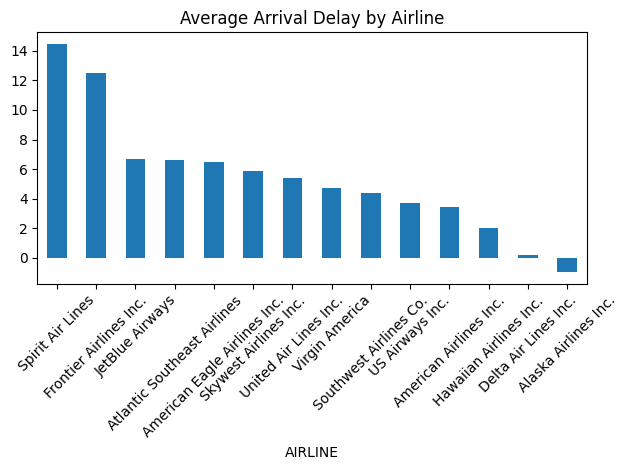

In [6]:
plot_delays_by_airline(results["delays_by_airline"])

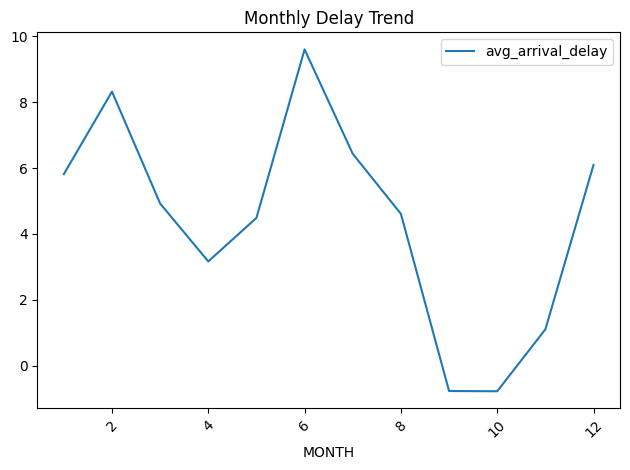

In [7]:
plot_monthly_delay(results["monthly_delay_trend"])

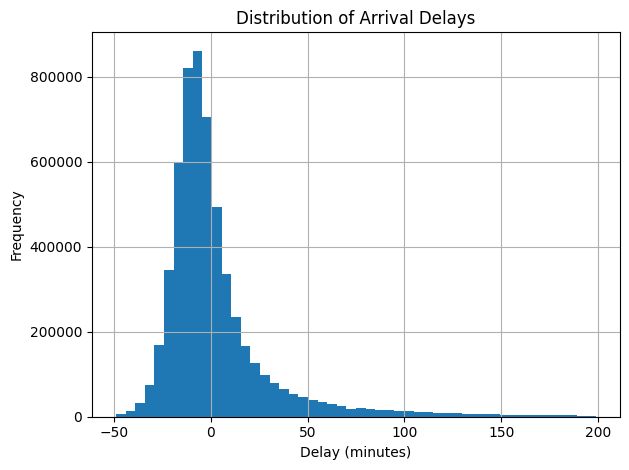

In [8]:
plot_delay_distribution(results["delay_distribution"])

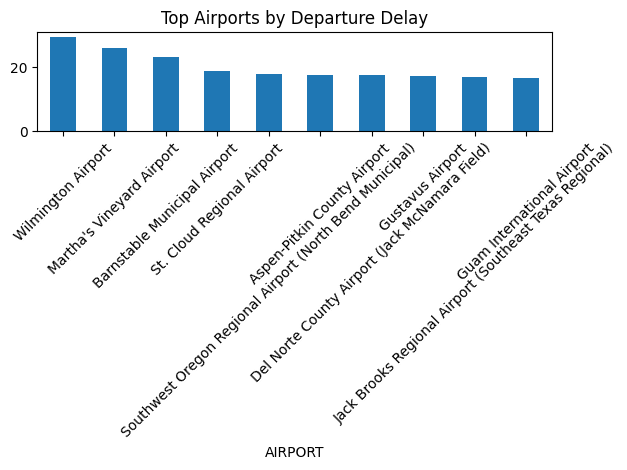

In [10]:
plot_top_delayed_airports(results["top_delayed_airports"])

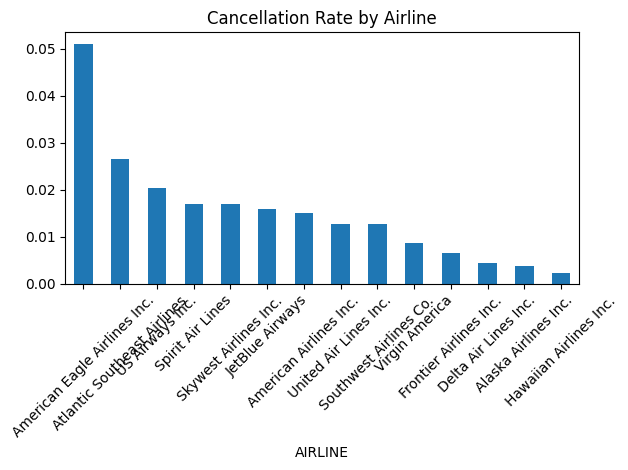

In [11]:
plot_cancellation_rate(results["cancellation_rate"])